# HW8

**С помощью предобученной модели StableDiffusion сгенерировать фотографии себя в разном окружении (в стиле киберпанка, из металла и тд).
Должно сохраниться ваше лицо!!!**
- Показать одно качественное изображение и еще 5
- Показать изображения, сгенерированные по тексту “<ваш пол> in a forest”, “<ваш пол> in a city”, “<ваш пол> in a beach”, с уточнениями “high quality, realism”
- Не использовать трансляцию из изображения в изображение
- Не использовать негативные промпты

In [86]:
!pip install diffusers transformers accelerate safetensors insightface onnxruntime -q

In [1]:
!mkdir -p /content/ip_adapter

!wget -q "https://huggingface.co/h94/IP-Adapter-FaceID/resolve/main/ip-adapter-faceid_sd15.bin" \
    -O /content/ip_adapter/ip-adapter-faceid_sd15.bin

In [88]:
!pip install ip-adapter -q

In [89]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from insightface.app import FaceAnalysis
from ip_adapter.ip_adapter_faceid import IPAdapterFaceID

In [90]:
model_id = "runwayml/stable-diffusion-v1-5"

scheduler = DDIMScheduler.from_pretrained(model_id, subfolder="scheduler")

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16,
)

pipe.safety_checker = None
pipe.requires_safety_checker = False

pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

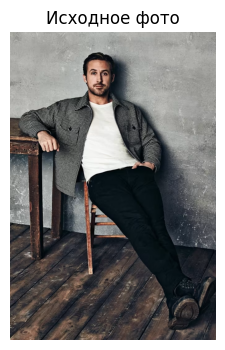

In [91]:
photo_path = "/content/my_photo"

photo_file = None
for f in os.listdir(photo_path):
    if f.lower().endswith(('.jpg', '.jpeg', '.png')):
        photo_file = os.path.join(photo_path, f)
        break

my_photo = Image.open(photo_file).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(my_photo)
plt.title("Исходное фото")
plt.axis("off")
plt.show()

In [92]:
app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

img_cv = cv2.imread(photo_file)
img_cv = cv2.resize(img_cv, (640, 640))

faces = app.get(img_cv)

if len(faces) == 0:
    print("Лицо не найдено")
else:
    print(f"Лицо найдено. Качество детекции: {faces[0].det_score:.2f}")
    face_embedding = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

In [93]:
ip_model = IPAdapterFaceID(
    pipe,
    "/content/ip_adapter/ip-adapter-faceid_sd15.bin",
    device="cuda"
)

  0%|          | 0/60 [00:00<?, ?it/s]

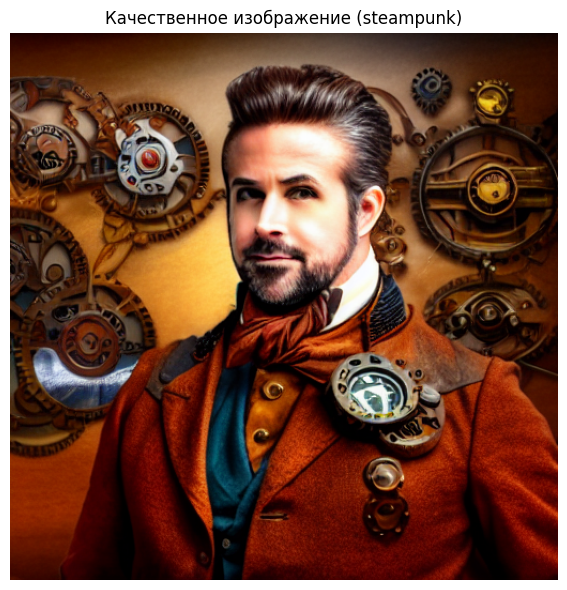

In [94]:
best_images = ip_model.generate(
    prompt="man in steampunk style, gears, victorian, high quality, detailed",
    faceid_embeds=face_embedding,
    num_samples=1,
    num_inference_steps=60,
    seed=42,
    guidance_scale=7.5,
    scale=0.8
)
best_image = best_images[0]

plt.figure(figsize=(6, 6))
plt.imshow(best_image)
plt.title("Качественное изображение (steampunk)", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig("/content/best_image.png", dpi=150)
plt.show()

In [95]:
prompts_5 = [
    "man in cyberpunk city, neon lights, high quality",
    "man made of metal, metall skin, high quality",
    "man in fantasy world, magic atmosphere, high quality",
    "man as a medieval knight, armor, sword, high quality",
    "man in space, astronaut, stars, moon, high quality",
]

images_5 = []

for i, prompt in enumerate(prompts_5):
    imgs = ip_model.generate(
        prompt=prompt,
        faceid_embeds=face_embedding,
        num_samples=1,
        num_inference_steps=30,
        seed=42,
        guidance_scale=7.5,
        scale=0.8
    )
    images_5.append((prompt, imgs[0]))

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

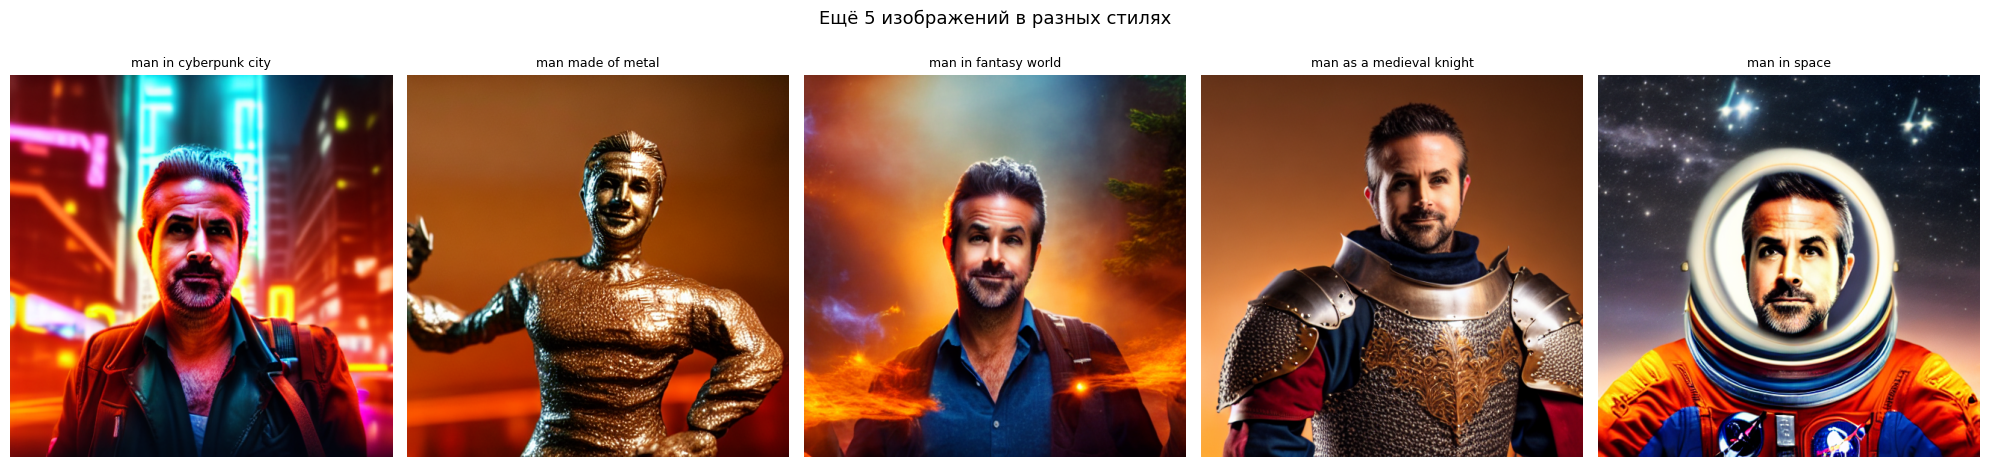

In [96]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (prompt, img) in enumerate(images_5):
    axes[i].imshow(img)
    short = prompt.split(",")[0]
    axes[i].set_title(short, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Ещё 5 изображений в разных стилях", fontsize=13)
plt.tight_layout()
plt.savefig("/content/styled_5.png", dpi=150)
plt.show()

In [97]:
location_prompts = [
    "man in a forest, high quality, realism",
    "man in a city, high quality, realism",
    "man in a beach, high quality, realism",
]

location_images = []

for i, prompt in enumerate(location_prompts):
    print(f"Генерирую {i+1}/3: {prompt}")

    imgs = ip_model.generate(
        prompt=prompt,
        faceid_embeds=face_embedding,
        num_samples=1,
        num_inference_steps=40,
        seed=123,
        guidance_scale=7.5,
        scale=0.8
    )
    location_images.append((prompt, imgs[0]))

Генерирую 1/3: man in a forest, high quality, realism


  0%|          | 0/40 [00:00<?, ?it/s]

Генерирую 2/3: man in a city, high quality, realism


  0%|          | 0/40 [00:00<?, ?it/s]

Генерирую 3/3: man in a beach, high quality, realism


  0%|          | 0/40 [00:00<?, ?it/s]

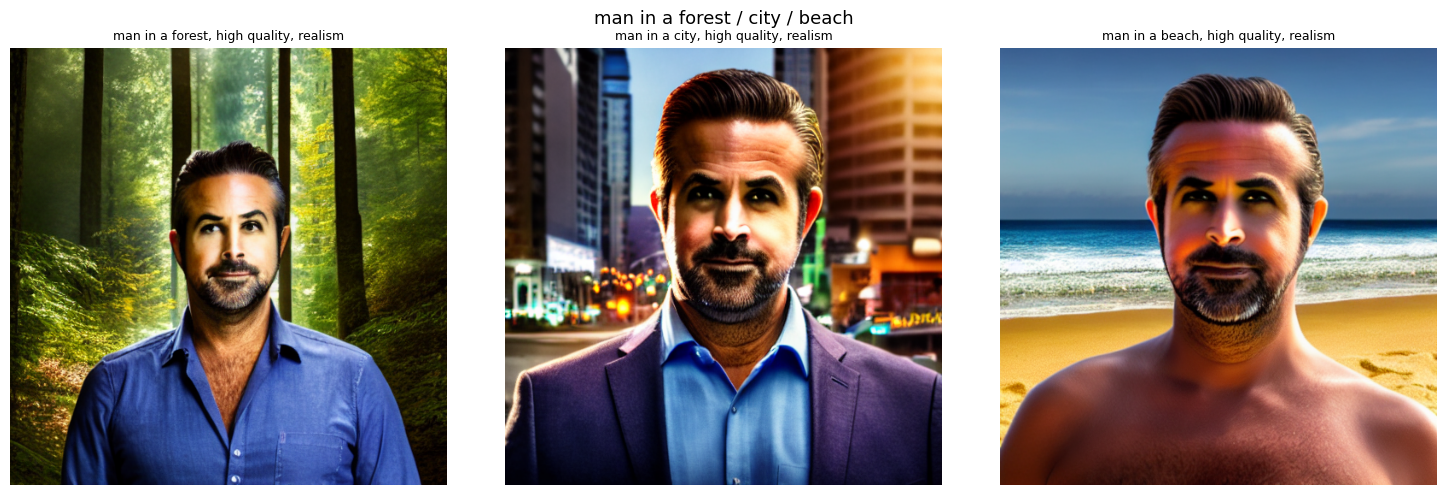

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (prompt, img) in enumerate(location_images):
    axes[i].imshow(img)
    axes[i].set_title(prompt, fontsize=9)
    axes[i].axis("off")

plt.suptitle("man in a forest / city / beach", fontsize=13)
plt.tight_layout()
plt.savefig("/content/location_images.png", dpi=150)
plt.show()